In [59]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import itertools


In [60]:
try:
    model = load_model('./my_plant_model.keras')
    print("✓ Loaded existing trained model")
    skip_build = True
except FileNotFoundError:
    print("No existing model found, will build new one")
    skip_build = False

✓ Loaded existing trained model


/Users/webergrillen/Vscode/ml_eksamen/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [61]:
archive_path = './Dataset'
print(f"Archive path: {archive_path}")

Archive path: ./Dataset


In [62]:
# List subfolder structure
import os
subfolders = [d for d in os.listdir(archive_path) if os.path.isdir(os.path.join(archive_path, d))]
print(f"Subfolders: {subfolders}")

Subfolders: ['test', 'New Plant Diseases Dataset(Augmented)']


In [63]:
IMAGE_SIZE = [100, 100]
epochs = 10
batch_size = 128

In [64]:
import os
import shutil

# Training files
trainingPath = './Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

# Validation files
validPath = './Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

# Test files - organize flat test folder into class subdirectories
testSourcePath = './Dataset/test/test'
testOrgPath = './Dataset/test/organized'

# Create class folders and organize test images
for filename in os.listdir(testSourcePath):
    if filename.endswith('.JPG'):
        # Extract class name (everything before the number)
        class_name = ''.join([c for c in filename if not c.isdigit()]).replace('.JPG', '')
        
        # Create class folder
        class_path = os.path.join(testOrgPath, class_name)
        os.makedirs(class_path, exist_ok=True)
        
        # Move file
        shutil.move(
            os.path.join(testSourcePath, filename),
            os.path.join(class_path, filename)
        )

print("Test images organized!")
testPath = testOrgPath

Test images organized!


In [65]:
from glob import glob

image_files = glob('./Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/*/*.jp*g')
folders = glob('./Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/*')


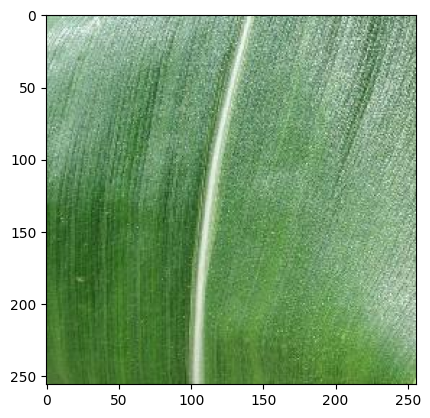

In [66]:
plt.imshow(image.load_img(np.random.choice(image_files)))

In [67]:
if not skip_build:
    print("Building new model...")
    
    resNet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
    
    for layer in resNet.layers:
        layer.trainable = False
    
    layers = Flatten()(resNet.output)
    layers = Dense(128, activation='relu')(layers)
    layers = Dropout(0.5)(layers)
    layers = Dense(128, activation='relu')(layers)
    layers = Dropout(0.4)(layers)
    layers = Dense(len(folders), activation='softmax')(layers)
    
    model = Model(inputs = resNet.input, outputs = layers)
    
    model.summary()
    
    from tensorflow.keras.optimizers import Adam
    model.compile(
        loss = 'sparse_categorical_crossentropy',
        optimizer = Adam(learning_rate=0.001),
        metrics = ['accuracy']
    )
else:
    print("Using loaded model, skipping build")

Using loaded model, skipping build


In [68]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

training_set = train_datagen.flow_from_directory(
    trainingPath,
    target_size=IMAGE_SIZE,
    shuffle=True,
    batch_size=batch_size,
    class_mode='sparse'
)

validation_set = test_datagen.flow_from_directory(
    validPath,
    target_size=IMAGE_SIZE,
    shuffle=False,
    batch_size=batch_size,
    class_mode='sparse'
)

test_set = test_datagen.flow_from_directory(
    testPath,
    target_size=IMAGE_SIZE,
    shuffle=False,
    batch_size=batch_size,
    class_mode='sparse'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 33 images belonging to 8 classes.


In [69]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(
    training_set,
    validation_data=validation_set,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 514s 923ms/step - accuracy: 0.2146 - loss: 2.6314 - val_accuracy: 0.3929 - val_loss: 2.0404
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 504s 915ms/step - accuracy: 0.2244 - loss: 2.6129 - val_accuracy: 0.3803 - val_loss: 2.0831
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 502s 912ms/step - accuracy: 0.2267 - loss: 2.6063 - val_accuracy: 0.3891 - val_loss: 2.0635
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 500s 910ms/step - accuracy: 0.2375 - loss: 2.5692 - val_accuracy: 0.4212 - val_loss: 1.9907
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 499s 907ms/step - accuracy: 0.2376 - loss: 2.5748 - val_accuracy: 0.3819 - val_loss: 2.0005
Epoch 6/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 498s 905ms/step - accuracy: 0.2421 - loss: 2.5508 - val_accuracy: 0.4215 - val_loss: 1.9410
Epoch 7/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 498s 905ms/step - accuracy: 0.2453 - loss: 2.5598 - val_accuracy: 0.4218 - val_loss: 1.9095
Epoch 8/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 511s 929ms/step - accuracy: 0.2494 -

In [70]:
test_results = model.evaluate(test_set)
print(f"Test accuracy: {test_results[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.0303 - loss: 4.7910
Test accuracy: 0.03030303120613098


In [71]:
model.save('./my_plant_model.keras')